In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE

load data training dan testing

In [42]:
train = pd.read_csv("data/processed/train_set_scaled.csv")
test  = pd.read_csv("data/processed/test_set_scaled.csv")

with open("data/models/fitur_names.json") as f:
    meta = json.load(f)

FITUR  = meta["fitur"]
TARGET = meta["target"]

X_train = train[FITUR].values
y_train = train[TARGET].values
X_test  = test[FITUR].values
y_test  = test[TARGET].values

print(f"X_train: {X_train.shape} | y_train distribusi: {pd.Series(y_train).value_counts().to_dict()}")
print(f"X_test : {X_test.shape}  | y_test  distribusi: {pd.Series(y_test).value_counts().to_dict()}")

X_train: (29600, 19) | y_train distribusi: {0: 29005, 1: 595}
X_test : (7401, 19)  | y_test  distribusi: {0: 7252, 1: 149}


handle class imbalance dengan smote

In [43]:
print(f"\nsebelum smote")
print(f"  train - normal : {sum(y_train==0):,}")
print(f"  train - anomali: {sum(y_train==1):,}")
print(f"  test  - normal : {sum(y_test==0):,}")
print(f"  test  - anomali: {sum(y_test==1):,}")

n_anomali_train = sum(y_train == 1)
k_smote = min(5, n_anomali_train - 1)
print(f"\njumlah sampel anomali di train: {n_anomali_train}")
print(f"k_neighbors smote yang dipakai : {k_smote}")

smote = SMOTE(random_state=42, k_neighbors=k_smote)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"\nsetelah smote:")
print(f"  train - normal : {sum(y_train==0):,}")
print(f"  train - anomali: {sum(y_train==1):,}")
print(f"  rasio normal:anomali = {sum(y_train==0)/sum(y_train==1):.2f}:1")


sebelum smote
  train - normal : 29,005
  train - anomali: 595
  test  - normal : 7,252
  test  - anomali: 149

jumlah sampel anomali di train: 595
k_neighbors smote yang dipakai : 5

setelah smote:
  train - normal : 29,005
  train - anomali: 29,005
  rasio normal:anomali = 1.00:1


cari nilai k optimal untuk kNN

In [44]:
k_values = list(range(1, 22, 2))  # 1, 3, 5, 7, ... 21
k_scores = {}

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    score = f1_score(y_test, y_pred_temp, zero_division=0)
    k_scores[k] = round(score, 4)
    print(f"  k={k:2d} → f1_score={score:.4f}")

best_k = max(k_scores, key=k_scores.get)
print(f"\nnilai k terbaik: {best_k} (f1_score={k_scores[best_k]:.4f})")

  k= 1 → f1_score=0.9470
  k= 3 → f1_score=0.9477
  k= 5 → f1_score=0.9385
  k= 7 → f1_score=0.9325
  k= 9 → f1_score=0.9148
  k=11 → f1_score=0.9091
  k=13 → f1_score=0.9062
  k=15 → f1_score=0.9040
  k=17 → f1_score=0.8957
  k=19 → f1_score=0.8743
  k=21 → f1_score=0.8698

nilai k terbaik: 3 (f1_score=0.9477)


visualisasi k vs f1-score

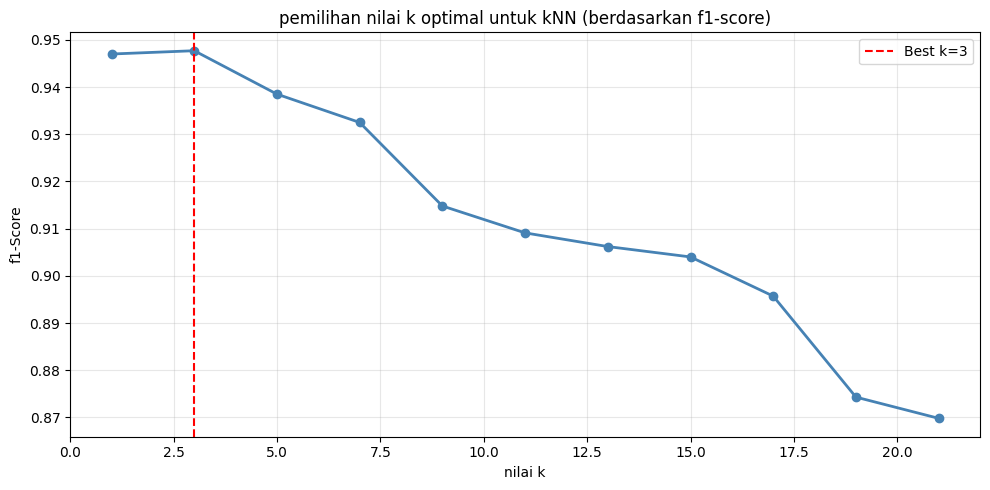

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(list(k_scores.keys()), list(k_scores.values()),
         marker="o", color="steelblue", linewidth=2)
plt.axvline(x=best_k, color="red", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("nilai k")
plt.ylabel("f1-Score")
plt.title("pemilihan nilai k optimal untuk kNN (berdasarkan f1-score)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/knn_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()

latih model kNN

In [46]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric="euclidean",
    n_jobs=-1
)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("hasil evaluasi kNN (sebelum threshold tuning)")
print(classification_report(y_test, y_pred_knn,
                             target_names=["normal", "anomali"]))

hasil evaluasi kNN (sebelum threshold tuning)
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      7252
     anomali       0.92      0.97      0.95       149

    accuracy                           1.00      7401
   macro avg       0.96      0.99      0.97      7401
weighted avg       1.00      1.00      1.00      7401



threshold tuning kNN

In [47]:
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# cari threshold optimal berdasarkan F1-Score tertinggi
precisions_knn, recalls_knn, thresholds_knn = precision_recall_curve(y_test, y_prob_knn)
f1s_knn = 2 * (precisions_knn * recalls_knn) / (precisions_knn + recalls_knn + 1e-10)
optimal_idx_knn = np.argmax(f1s_knn)
optimal_threshold_knn = (
    thresholds_knn[optimal_idx_knn]
    if optimal_idx_knn < len(thresholds_knn)
    else 0.5
)

print(f"default threshold : 0.5")
print(f"optimal threshold : {optimal_threshold_knn:.4f}")

# prediksi dengan threshold optimal
y_pred_knn_tuned = (y_prob_knn >= optimal_threshold_knn).astype(int)

print("\nhasil evaluasi kNN (setelah threshold tuning)")
print(classification_report(y_test, y_pred_knn_tuned,
                             target_names=["Normal", "Anomali"]))

default threshold : 0.5
optimal threshold : 0.6667

hasil evaluasi kNN (setelah threshold tuning)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7252
     Anomali       0.92      0.97      0.95       149

    accuracy                           1.00      7401
   macro avg       0.96      0.99      0.97      7401
weighted avg       1.00      1.00      1.00      7401



In [48]:
knn_metrics = {
    "model"     : "kNN",
    "best_k"    : best_k,
    "threshold" : round(float(optimal_threshold_knn), 4),
    "accuracy"  : round(accuracy_score(y_test,  y_pred_knn_tuned), 4),
    "precision" : round(precision_score(y_test, y_pred_knn_tuned, zero_division=0), 4),
    "recall"    : round(recall_score(y_test,    y_pred_knn_tuned, zero_division=0), 4),
    "f1_score"  : round(f1_score(y_test,        y_pred_knn_tuned, zero_division=0), 4),
}
print(knn_metrics)

{'model': 'kNN', 'best_k': 3, 'threshold': 0.6667, 'accuracy': 0.9978, 'precision': 0.9236, 'recall': 0.9732, 'f1_score': 0.9477}


confusion matrix kNN

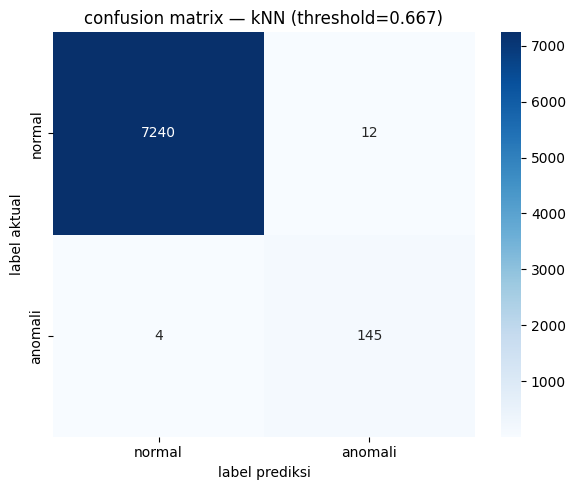

In [49]:
plt.figure(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, y_pred_knn_tuned)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "anomali"],
            yticklabels=["normal", "anomali"])
plt.title(f"confusion matrix — kNN (threshold={optimal_threshold_knn:.3f})")
plt.ylabel("label aktual")
plt.xlabel("label prediksi")
plt.tight_layout()
plt.savefig("data/processed/cm_knn.png", dpi=150, bbox_inches="tight")
plt.show()

simpan model kNN

In [50]:
joblib.dump(knn_model, "data/models/knn_model.pkl")

['data/models/knn_model.pkl']

cari c optimal dan latih logistic regression

In [51]:
C_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
c_scores = {}

for C in C_values:
    lr_temp = LogisticRegression(
        C=C, max_iter=1000, random_state=42
    )
    lr_temp.fit(X_train, y_train)
    y_pred_temp = lr_temp.predict(X_test)
    score = f1_score(y_test, y_pred_temp, zero_division=0)
    c_scores[C] = round(score, 4)
    print(f"  C={C:5.2f} → f1_score={score:.4f}")

best_C = max(c_scores, key=c_scores.get)
print(f"\nnilai C terbaik: {best_C} (f1_score={c_scores[best_C]:.4f})")

  C= 0.01 → f1_score=0.7807
  C= 0.10 → f1_score=0.8222
  C= 0.50 → f1_score=0.8362
  C= 1.00 → f1_score=0.8457
  C= 5.00 → f1_score=0.8963
  C=10.00 → f1_score=0.9130
  C=50.00 → f1_score=0.9187
  C=100.00 → f1_score=0.9216

nilai C terbaik: 100.0 (f1_score=0.9216)


In [52]:
lr_model = LogisticRegression(
    C=best_C,
    max_iter=1000,
    random_state=42,
    solver="lbfgs"
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("hasil evaluasi logistic regression (sebelum threshold tuning)")
print(classification_report(y_test, y_pred_lr,
                             target_names=["normal", "anomali"]))

hasil evaluasi logistic regression (sebelum threshold tuning)
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      7252
     anomali       0.86      0.99      0.92       149

    accuracy                           1.00      7401
   macro avg       0.93      0.99      0.96      7401
weighted avg       1.00      1.00      1.00      7401



threshold tuning logistic regression

In [53]:
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

precisions_lr, recalls_lr, thresholds_lr = precision_recall_curve(y_test, y_prob_lr)
f1s_lr = 2 * (precisions_lr * recalls_lr) / (precisions_lr + recalls_lr + 1e-10)
optimal_idx_lr = np.argmax(f1s_lr)
optimal_threshold_lr = (
    thresholds_lr[optimal_idx_lr]
    if optimal_idx_lr < len(thresholds_lr)
    else 0.5
)

print(f"default threshold : 0.5")
print(f"optimal threshold : {optimal_threshold_lr:.4f}")

y_pred_lr_tuned = (y_prob_lr >= optimal_threshold_lr).astype(int)

print("\nhasil evaluasi logistic regression (setelah threshold tuning)")
print(classification_report(y_test, y_pred_lr_tuned,
                             target_names=["normal", "anomali"]))

default threshold : 0.5
optimal threshold : 0.8939

hasil evaluasi logistic regression (setelah threshold tuning)
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      7252
     anomali       0.92      0.99      0.95       149

    accuracy                           1.00      7401
   macro avg       0.96      0.99      0.98      7401
weighted avg       1.00      1.00      1.00      7401



In [54]:
lr_metrics = {
    "model"     : "Logistic Regression",
    "best_C"    : best_C,
    "threshold" : round(float(optimal_threshold_lr), 4),
    "accuracy"  : round(accuracy_score(y_test,  y_pred_lr_tuned), 4),
    "precision" : round(precision_score(y_test, y_pred_lr_tuned, zero_division=0), 4),
    "recall"    : round(recall_score(y_test,    y_pred_lr_tuned, zero_division=0), 4),
    "f1_score"  : round(f1_score(y_test,        y_pred_lr_tuned, zero_division=0), 4),
}
print(lr_metrics)

{'model': 'Logistic Regression', 'best_C': 100.0, 'threshold': 0.8939, 'accuracy': 0.998, 'precision': 0.9187, 'recall': 0.9866, 'f1_score': 0.9515}


confusion matrix logistic regression

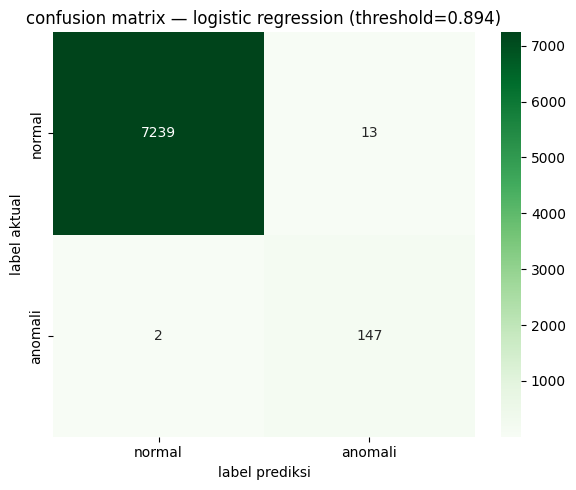

In [55]:
plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr_tuned)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens",
            xticklabels=["normal", "anomali"],
            yticklabels=["normal", "anomali"])
plt.title(f"confusion matrix — logistic regression (threshold={optimal_threshold_lr:.3f})")
plt.ylabel("label aktual")
plt.xlabel("label prediksi")
plt.tight_layout()
plt.savefig("data/processed/cm_lr.png", dpi=150, bbox_inches="tight")
plt.show()

simpan model logistic regression

In [56]:
joblib.dump(lr_model, "data/models/lr_model.pkl")

['data/models/lr_model.pkl']

perbandingan kNN dan logistic regression

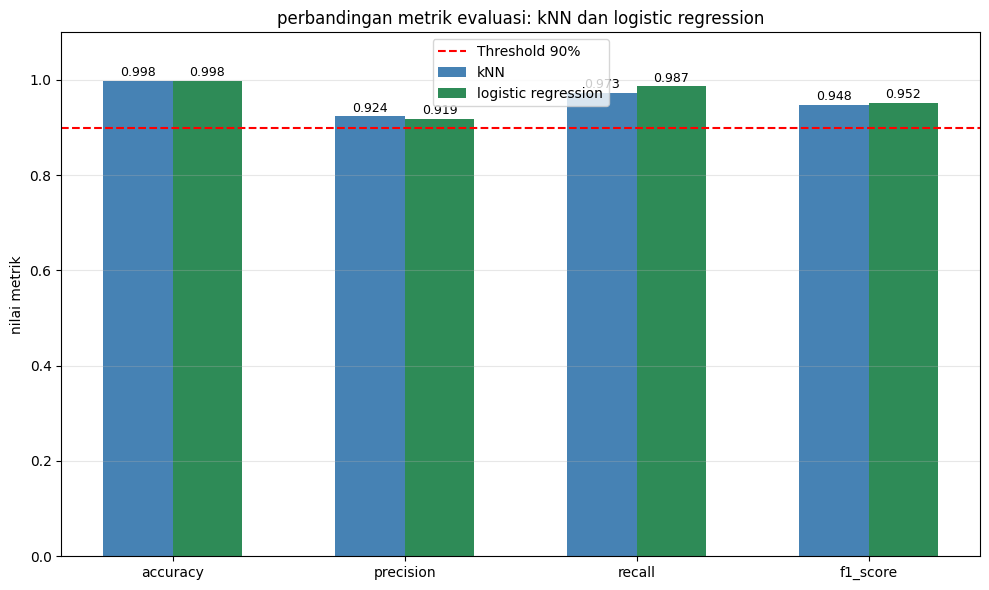

In [57]:
metrik_labels = ["accuracy", "precision", "recall", "f1_score"]
knn_vals = [knn_metrics[m] for m in metrik_labels]
lr_vals  = [lr_metrics[m]  for m in metrik_labels]

x = np.arange(len(metrik_labels))
width = 0.3

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, knn_vals, width, label="kNN", color="steelblue")
plt.bar(x + width/2, lr_vals,  width, label="logistic regression", color="seagreen")
plt.axhline(y=0.90, color="red", linestyle="--", linewidth=1.5, label="Threshold 90%")
plt.xticks(x, ["accuracy", "precision", "recall", "f1_score"])
plt.ylabel("nilai metrik")
plt.ylim(0, 1.1)
plt.title("perbandingan metrik evaluasi: kNN dan logistic regression")
plt.legend()
plt.grid(axis="y", alpha=0.3)
for i, (v1, v2) in enumerate(zip(knn_vals, lr_vals)):
    plt.text(i - width/2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=9)
    plt.text(i + width/2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("data/processed/perbandingan_model.png", dpi=150, bbox_inches="tight")
plt.show()

pengecekan apakah memenuhi threshold ≥ 90%

In [58]:
def cek_kelayakan(nama, metrics):
    print(f"\n  model: {nama}")
    lulus = True
    for m in ["accuracy", "precision", "recall", "f1_score"]:
        val = metrics[m]
        status = "lulus" if val >= 0.90 else "perlu perbaikan"
        print(f"    {m:10s}: {val:.4f} ({val*100:.2f}%) → {status}")
        if val < 0.90:
            lulus = False
    print(f"  Kesimpulan: {'model layak' if lulus else 'perlu tuning ulang'}")
    return lulus

knn_lulus = cek_kelayakan("kNN", knn_metrics)
lr_lulus  = cek_kelayakan("logistic regression", lr_metrics)


  model: kNN
    accuracy  : 0.9978 (99.78%) → lulus
    precision : 0.9236 (92.36%) → lulus
    recall    : 0.9732 (97.32%) → lulus
    f1_score  : 0.9477 (94.77%) → lulus
  Kesimpulan: model layak

  model: logistic regression
    accuracy  : 0.9980 (99.80%) → lulus
    precision : 0.9187 (91.87%) → lulus
    recall    : 0.9866 (98.66%) → lulus
    f1_score  : 0.9515 (95.15%) → lulus
  Kesimpulan: model layak


menyimpan semua matrik ke json

In [59]:
all_metrics = {
    "knn": knn_metrics,
    "logistic_regression": lr_metrics
}
with open("data/models/metrics_awal.json", "w") as f:
    json.dump(all_metrics, f, indent=2)

print(f"\nringkasan:")
print(f"  kNN (k={best_k}, threshold={optimal_threshold_knn:.3f}): "
      f"acc={knn_metrics['accuracy']}, f1={knn_metrics['f1_score']}")
print(f"  logistic regression (C={best_C}, threshold={optimal_threshold_lr:.3f}) : "
      f"acc={lr_metrics['accuracy']},  f1={lr_metrics['f1_score']}")


ringkasan:
  kNN (k=3, threshold=0.667): acc=0.9978, f1=0.9477
  logistic regression (C=100.0, threshold=0.894) : acc=0.998,  f1=0.9515


In [60]:
# Cek confusion matrix LR
cm_lr_check = confusion_matrix(y_test, lr_model.predict(X_test))
print("Confusion Matrix — Logistic Regression:")
print(f"  TN={cm_lr_check[0,0]}  FP={cm_lr_check[0,1]}")
print(f"  FN={cm_lr_check[1,0]}  TP={cm_lr_check[1,1]}")

# Cek apakah model terlalu agresif prediksi anomali
pred_lr_check = lr_model.predict(X_test)
print(f"\nPrediksi LR: {(pred_lr_check==1).sum()} anomali, {(pred_lr_check==0).sum()} normal")
print(f"Ground truth: {(y_test==1).sum()} anomali, {(y_test==0).sum()} normal")

Confusion Matrix — Logistic Regression:
  TN=7229  FP=23
  FN=2  TP=147

Prediksi LR: 170 anomali, 7231 normal
Ground truth: 149 anomali, 7252 normal
